**TAHAP 1: BUSINESS & DATA UNDERSTANDING**

Tahap awal untuk identifikasi awal dataset perolehan suara dan tingkat partisipasi politik. Pada tahap ini, dilakukan audit kelengkapan data terhadap 12 parameter penelitian guna memastikan setiap baris data kecamatan memiliki nilai yang valid dan lengkap. Seluruh rekapitulasi pemeriksaan data ini diekspor ke dalam format Excel sebagai bagian dari dokumentasi pengolahan data mentah.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

# ==========================================================
# 1. LOAD DATASET
# ==========================================================
nama_file_input = 'data_kmeans_clustering.xlsx'
df = pd.read_excel(nama_file_input)

# ==========================================================
# 2. DEFINISI PARAMETER
# ==========================================================
fitur_cols = [
    '%_v_pres', '%_v_pileg_ri', '%_v_pileg_prov', '%_v_pileg_kokab',
    '%_v_pilkada_gub', '%_v_pilkada_kokab', 
    '%_part_pilpres', '%_part_pileg_ri', '%_part_pileg_prov', 
    '%_part_pileg_kab', '%_part_pilkada_gub', '%_part_pilkada_kokab'
]

# ==========================================================
# 3. CLEANING DATA
# ==========================================================
summary_und = df[fitur_cols].isnull().sum().reset_index()
summary_und.columns = ['Nama Parameter', 'Jumlah Data Kosong']
summary_und['Total Baris'] = len(df)
summary_und['Status'] = 'Data Lengkap'

# Menampilkan Ringkasan Data ke Layar
print("=== RINGKASAN DATA ===")
print("-" * 80)
print(summary_und.to_string(index=False))
print("-" * 80)

# ==========================================================
# 4. EXPORT LAPORAN AUDIT DATA KE EXCEL
# ==========================================================
nama_file_t1 = "Kelengkapan_Data_Cleaning.xlsx"
summary_und.to_excel(nama_file_t1, index=False)

print(f"\n[INFO] Berkas Laporan Tahap 1 telah dihasilkan: {nama_file_t1}")


=== RINGKASAN DATA ===
--------------------------------------------------------------------------------
      Nama Parameter  Jumlah Data Kosong  Total Baris       Status
            %_v_pres                   0          627 Data Lengkap
        %_v_pileg_ri                   0          627 Data Lengkap
      %_v_pileg_prov                   0          627 Data Lengkap
     %_v_pileg_kokab                   0          627 Data Lengkap
     %_v_pilkada_gub                   0          627 Data Lengkap
   %_v_pilkada_kokab                   0          627 Data Lengkap
      %_part_pilpres                   0          627 Data Lengkap
     %_part_pileg_ri                   0          627 Data Lengkap
   %_part_pileg_prov                   0          627 Data Lengkap
    %_part_pileg_kab                   0          627 Data Lengkap
  %_part_pilkada_gub                   0          627 Data Lengkap
%_part_pilkada_kokab                   0          627 Data Lengkap
-------------------------

**TAHAP 2: DATA PREPARATION (STANDARISASI DATA)**

Tahap penyiapan data melalui proses standarisasi (Z-Score). Karena 12 parameter penelitian memiliki rentang angka yang berbeda-beda, kita perlu menyamakan skalanya agar setiap variabel memiliki bobot yang adil dalam proses pengelompokan nanti. Hasil dari penyesuaian angka ini disimpan ke dalam file Excel sebagai data yang sudah siap untuk diolah secara statistik.

In [2]:
# ==========================================================
# 1. PROSES NORMALISASI (Z-SCORE)
# ==========================================================
# Langkah ini untuk menyamakan skala 12 parameter agar seimbang (Mean=0, Std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[fitur_cols])

# ==========================================================
# 2. PENYUSUNAN KEMBALI DATAFRAME (DF_FINAL)
# ==========================================================
# Memasukkan kembali identitas wilayah (ID, Kab/Kota, Kecamatan) agar data tidak tertukar
df_final = pd.DataFrame(X_scaled, columns=fitur_cols)
df_final.insert(0, 'nama_kecamatan', df['nama_kecamatan'].values)
df_final.insert(0, 'kab_kota', df['kab_kota'].values)
df_final.insert(0, 'id_kec', df['id_kec'].values)

# ==========================================================
# 3. PENGECEKAN HASIL (SAMPEL 10 BARIS)
# ==========================================================
# Menampilkan 10 data secara acak untuk melihat perubahan angka setelah proses standarisasi
sampel_10 = df_final.sample(n=10, random_state=42)

print("=== TAMPILAN SAMPEL DATA HASIL STANDARISASI  ===")
print("-" * 130)
print(sampel_10.to_string(index=False))
print("-" * 130)

# ==========================================================
# 4. EXPORT DATA HASIL PREPARASI KE EXCEL
# ==========================================================
nama_file_t2 = "Hasil_Normalisasi_ZScore.xlsx"
df_final.to_excel(nama_file_t2, index=False)

print(f"\n[INFO] Berkas Laporan Tahap 2 telah dihasilkan: {nama_file_t2}")


=== TAMPILAN SAMPEL DATA HASIL STANDARISASI  ===
----------------------------------------------------------------------------------------------------------------------------------
 id_kec    kab_kota nama_kecamatan  %_v_pres  %_v_pileg_ri  %_v_pileg_prov  %_v_pileg_kokab  %_v_pilkada_gub  %_v_pilkada_kokab  %_part_pilpres  %_part_pileg_ri  %_part_pileg_prov  %_part_pileg_kab  %_part_pilkada_gub  %_part_pilkada_kokab
 321118    SUMEDANG SUMEDANG UTARA  0.466942     -0.783284       -1.078330        -0.418756         1.190213           0.018826        1.101908         1.151838           0.832095          1.148674            1.143322              1.248373
 320611 TASIKMALAYA   BOJONGGAMBIR -0.875606      1.903378        1.779905         3.271676        -0.677251          -0.634782       -1.088693        -1.057039          -1.659731         -1.025455            0.078244             -0.076785
 320215    SUKABUMI   PARAKANSALAK -0.143892      1.082675       -1.049183        -0.029756        -

**TAHAP 3: MODELING (PENCARIAN JUMLAH KLASTER TERBAIK)**

Tahap pembentukan model clustering untuk menentukan jumlah kelompok wilayah (K) yang paling tepat. Kita menggunakan tiga metode pengujian statistik secara bersamaan (Elbow, Silhouette, dan Davies-Bouldin) agar hasil pembagian zona wilayah didasari oleh bukti matematis yang kuat. Dokumentasi angka pengujian ini disimpan dalam format Excel sebagai landasan ilmiah dalam menentukan jumlah klaster akhir.

Sedang memproses perhitungan validasi otomatis...
---------------------------------------------------------------------------
K= 2 | SSE:5,212 | Silh:0.270 | DBI:1.395
K= 3 | SSE:4,363 | Silh:0.209 | DBI:1.560
K= 4 | SSE:3,833 | Silh:0.204 | DBI:1.456
K= 5 | SSE:3,556 | Silh:0.196 | DBI:1.505
K= 6 | SSE:3,336 | Silh:0.180 | DBI:1.695
K= 7 | SSE:3,137 | Silh:0.186 | DBI:1.572
K= 8 | SSE:2,983 | Silh:0.159 | DBI:1.615
K= 9 | SSE:2,825 | Silh:0.172 | DBI:1.540
K=10 | SSE:2,694 | Silh:0.175 | DBI:1.499
---------------------------------------------------------------------------


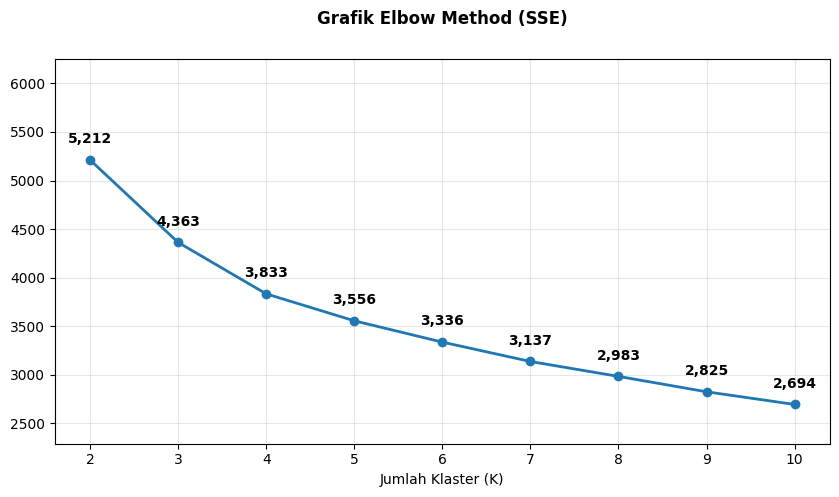

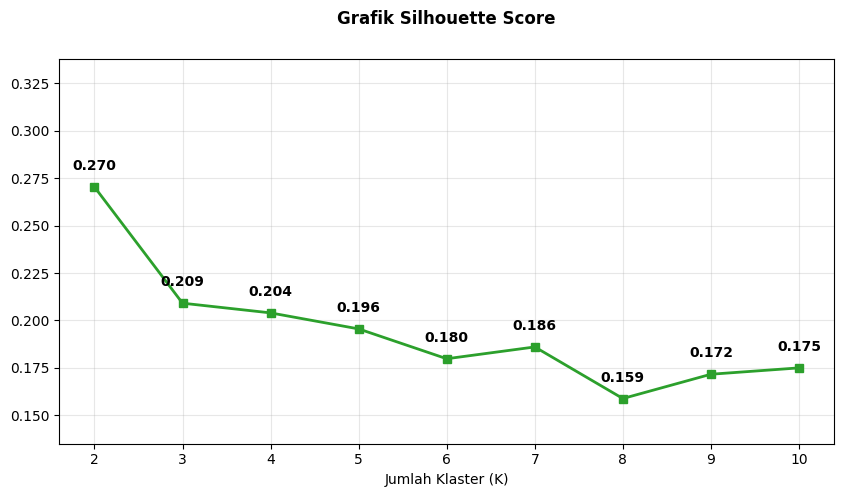

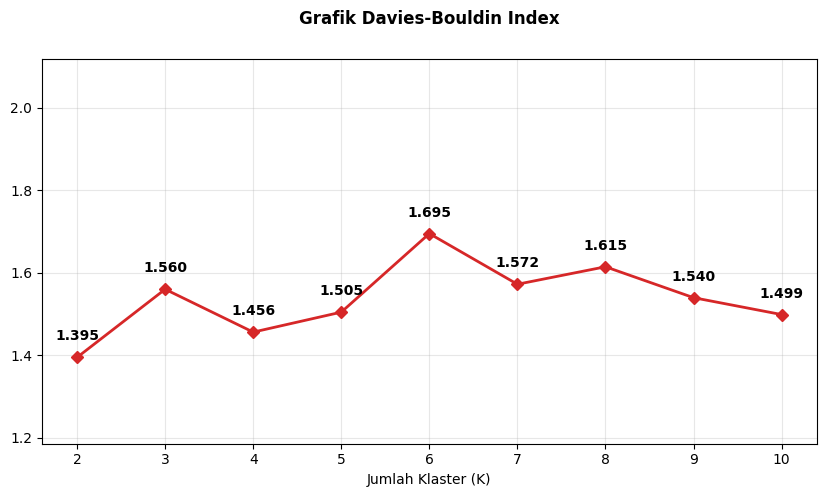


[INFO] Laporan Tahap 3 telah dicetak: Hasil_Validasi_Modeling_K.xlsx


In [3]:
# ==========================================================
# 1. PERHITUNGAN VALIDASI K-OPTIMAL (RANGE 2-10)
# ==========================================================
k_range = range(2, 11)
list_sse, list_silhouette, list_dbi = [], [], []

print("Sedang memproses perhitungan validasi otomatis...")
print("-" * 75)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    list_sse.append(kmeans.inertia_)
    list_silhouette.append(silhouette_score(X_scaled, labels))
    list_dbi.append(davies_bouldin_score(X_scaled, labels))
    
    # Tabel angka print di layar
    print(f"K={k:2d} | SSE:{list_sse[-1]:,.0f} | Silh:{list_silhouette[-1]:.3f} | DBI:{list_dbi[-1]:.3f}")

print("-" * 75)

# ==========================================================
# 2. VISUALISASI GRAFIK TERPISAH (GAYA JUDUL MULAI KATA GRAFIK)
# ==========================================================

# --- GRAFIK 1: ELBOW METHOD ---
plt.figure(figsize=(10, 5))
plt.plot(k_range, list_sse, marker='o', color='#1f77b4', linewidth=2)
plt.ylim(min(list_sse)*0.85, max(list_sse)*1.20) 
for i, val in enumerate(list_sse):
    plt.annotate(f'{val:,.0f}', (list(k_range)[i], list_sse[i]), 
                 ha='center', va='bottom', fontweight='bold', textcoords="offset points", xytext=(0,10))
plt.title('Grafik Elbow Method (SSE)', fontweight='bold', pad=25)
plt.xlabel('Jumlah Klaster (K)')
plt.grid(True, alpha=0.3)
plt.show()

print("\n") 

# --- GRAFIK 2: SILHOUETTE SCORE ---
plt.figure(figsize=(10, 5))
plt.plot(k_range, list_silhouette, marker='s', color='#2ca02c', linewidth=2)
plt.ylim(min(list_silhouette)*0.85, max(list_silhouette)*1.25)
for i, val in enumerate(list_silhouette):
    plt.annotate(f'{val:.3f}', (list(k_range)[i], list_silhouette[i]), 
                 ha='center', va='bottom', fontweight='bold', textcoords="offset points", xytext=(0,10))
plt.title('Grafik Silhouette Score', fontweight='bold', pad=25)
plt.xlabel('Jumlah Klaster (K)')
plt.grid(True, alpha=0.3)
plt.show()

print("\n") 

# --- GRAFIK 3: DAVIES-BOULDIN INDEX ---
plt.figure(figsize=(10, 5))
plt.plot(k_range, list_dbi, marker='D', color='#d62728', linewidth=2)
plt.ylim(min(list_dbi)*0.85, max(list_dbi)*1.25)
for i, val in enumerate(list_dbi):
    plt.annotate(f'{val:.3f}', (list(k_range)[i], list_dbi[i]), 
                 ha='center', va='bottom', fontweight='bold', textcoords="offset points", xytext=(0,10))
plt.title('Grafik Davies-Bouldin Index', fontweight='bold', pad=25)
plt.xlabel('Jumlah Klaster (K)')
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================================
# 3. EXPORT HASIL PENGUJIAN KE EXCEL
# ==========================================================
df_val_excel = pd.DataFrame({
    'K': list(k_range), 'SSE': list_sse, 'Silhouette': list_silhouette, 'DBI': list_dbi
})
df_val_excel.to_excel("Hasil_Validasi_Modeling_K.xlsx", index=False)
print(f"\n[INFO] Laporan Tahap 3 telah dicetak: Hasil_Validasi_Modeling_K.xlsx")


**TAHAP 4: MODEL EXECUTION (FINAL RUN & PCA)**

Tahap implementasi model clustering menggunakan jumlah kelompok yang telah ditentukan (K=5). Pada tahap ini, kita menghitung sebaran kecamatan di setiap zona wilayah dan memvisualisasikannya melalui teknik PCA (Principal Component Analysis). Proses PCA dilakukan untuk mereduksi 12 dimensi parameter menjadi 2 dimensi visual agar pola persebaran antar klaster dapat diamati secara spasial. Laporan distribusi kecamatan diekspor ke format Excel sebagai basis data zonasi.

=== REKAPITULASI DISTRIBUSI SEBARAN KLASTER (TAHAP 4) ===
-----------------------------------------------------------------
Label Klaster  Jumlah Kecamatan  Persentase (%)
            0               142           22.65
            1                88           14.04
            2               124           19.78
            3                67           10.69
            4               206           32.85
        Total               627          100.00
-----------------------------------------------------------------


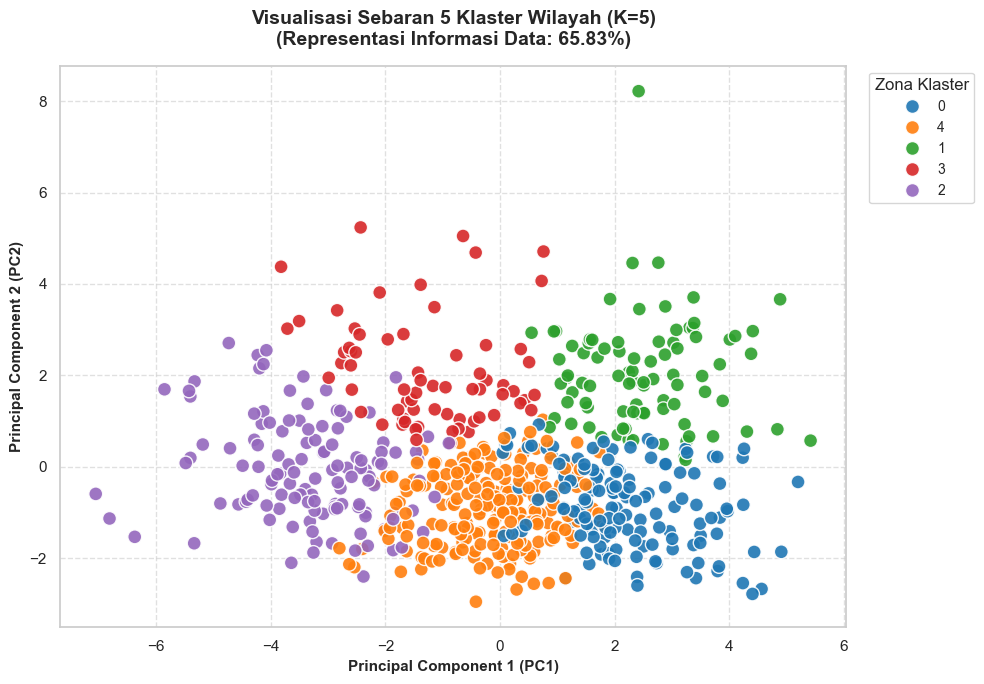


[INFO] Berkas Laporan Tahap 4 (Distribusi Wilayah) telah dihasilkan: Hasil_Distribusi_Zonasi_K5.xlsx


In [ ]:
# ==========================================================
# 1. PENETAPAN K FINAL & EKSEKUSI K-MEANS
# ==========================================================
# Menjalankan algoritma K-Means dengan K=5 (Berdasarkan hasil validasi Tahap 3)
k_final = 4 
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df['Cluster_Label'] = kmeans_final.fit_predict(X_scaled)

# ==========================================================
# 2. EVALUASI DISTRIBUSI WILAYAH (LOGIKA TOTAL)
# ==========================================================
# Menghitung jumlah perolehan kecamatan per klaster dan persentasenya
dist = df['Cluster_Label'].value_counts().sort_index().reset_index()
dist.columns = ['Label Klaster', 'Jumlah Kecamatan']
dist['Persentase (%)'] = (dist['Jumlah Kecamatan'] / len(df) * 100).round(2)

# Penambahan Baris Total sebagai validasi akhir jumlah data
baris_total = pd.DataFrame({
    'Label Klaster': ['Total'],
    'Jumlah Kecamatan': [dist['Jumlah Kecamatan'].sum()],
    'Persentase (%)': [100.0]
})
tabel_distribusi_final = pd.concat([dist, baris_total], ignore_index=True)

print("=== REKAPITULASI DISTRIBUSI SEBARAN KLASTER (TAHAP 4) ===")
print("-" * 65)
print(tabel_distribusi_final.to_string(index=False))
print("-" * 65)

# ==========================================================
# 3. VISUALISASI SEBARAN KLASTER (MENGGUNAKAN PCA)
# ==========================================================
# Mereduksi 12 Parameter menjadi 2 Principal Components (PC1 & PC2)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
acc_pca = np.sum(pca.explained_variance_ratio_) * 100 # Menghitung representasi data

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['Cluster_Label'].astype(str)

# UKURAN NORMAL (10x7 inci, Tanpa DPI Tambahan)
plt.figure(figsize=(10, 7)) 
sns.set_theme(style="whitegrid", palette="muted")

# Scatter plot dengan ukuran titik proporsional (s=100)
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, 
                palette='tab10', s=100, alpha=0.9, edgecolor='white', linewidth=1)

# JUDUL SUDAH SAYA PERBAIKI: "Visualisasi Sebaran"
plt.title(f'Visualisasi Sebaran 5 Klaster Wilayah (K={k_final})\n(Representasi Informasi Data: {acc_pca:.2f}%)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Principal Component 1 (PC1)', fontweight='bold', fontsize=11)
plt.ylabel('Principal Component 2 (PC2)', fontweight='bold', fontsize=11)
plt.legend(title='Zona Klaster', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ==========================================================
# 4. EXPORT HASIL DISTRIBUSI K KE EXCEL
# ==========================================================
nama_file_t4 = f"Hasil_Distribusi_Zonasi_K{k_final}.xlsx"
tabel_distribusi_final.to_excel(nama_file_t4, index=False)

print(f"\n[INFO] Berkas Laporan Tahap 4 (Distribusi Wilayah) telah dihasilkan: {nama_file_t4}")


**TAHAP 5: EVALUATION (PROFILING & KNOWLEDGE DISCOVERY)**

Tahap akhir penelitian untuk menemukan pengetahuan melalui interpretasi setiap kelompok wilayah (Klaster). Di sini kita membedah nilai rata-rata (Centroid) dari 12 parameter pada setiap klaster guna mengidentifikasi karakteristik unik di tingkat kecamatan secara objektif. Melalui visualisasi Heatmap, pola perbedaan perilaku pemilih dan tingkat partisipasi antar zona wilayah akan terlihat jelas sebagai dasar pengambilan kesimpulan riset. Seluruh data hasil pengelompokan akhir diekspor ke format Excel sebagai luaran (output) utama penelitian.

=== TABEL EVALUASI PROFIL KARAKTERISTIK (CENTROID TAHAP 5) ===
-----------------------------------------------------------------------------------------------------------------------------------------------------------
 Label_Klaster  Jumlah_Kecamatan  %_v_pres  %_v_pileg_ri  %_v_pileg_prov  %_v_pileg_kokab  %_v_pilkada_gub  %_v_pilkada_kokab  %_part_pilpres  %_part_pileg_ri  %_part_pileg_prov  %_part_pileg_kab  %_part_pilkada_gub  %_part_pilkada_kokab
             0               142     64.60         13.09           14.48            11.24            68.70              52.44           85.12            84.94              84.96             84.94               74.00                 73.29
             1                88     65.76         24.73           24.79            20.17            70.52              49.17           85.66            85.45              85.46             85.35               72.94                 71.98
             2               124     60.05         14.70           

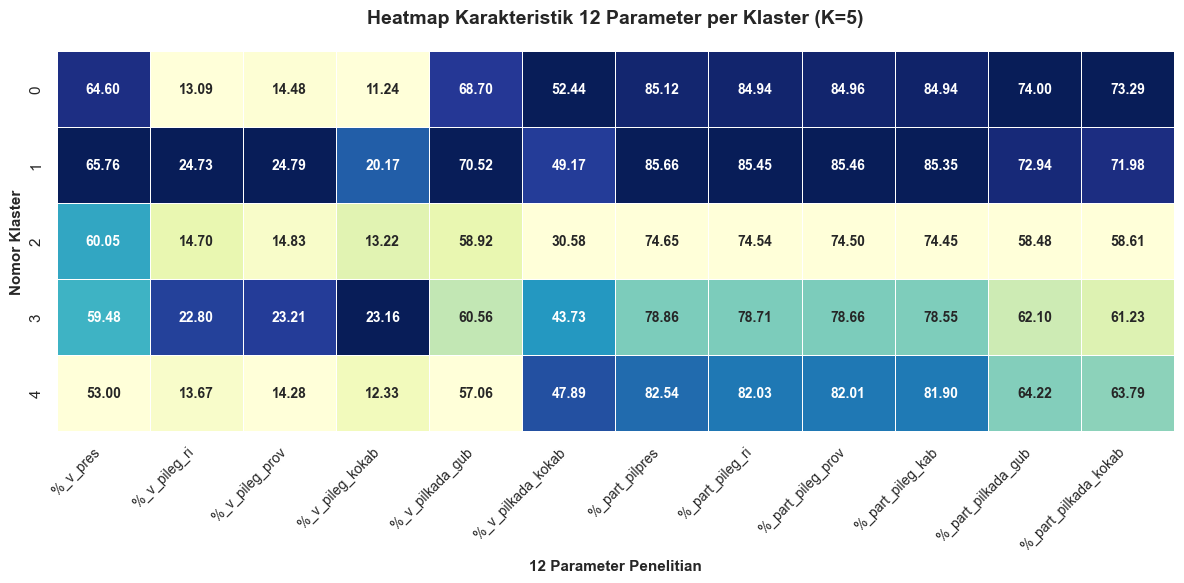


[INFO] Berkas Laporan Akhir Berhasil Dihasilkan:
1. Evaluasi_Profiling_Centroid_K5.xlsx
2. Master_Data_Berlabel_Final_K5.xlsx

=== SELURUH TAHAPAN CRISP-DM TELAH SELESAI ===


In [5]:
# ==========================================================
# 1. ANALISIS KARAKTERISTIK (PROFILING CENTROID)
# ==========================================================
tabel_profiling = df.groupby('Cluster_Label')[fitur_cols].mean().round(2)
tabel_profiling.insert(0, 'Jumlah_Kecamatan', df['Cluster_Label'].value_counts().sort_index())

tabel_profiling = tabel_profiling.reset_index()
tabel_profiling.rename(columns={'Cluster_Label': 'Label_Klaster'}, inplace=True)

print("=== TABEL EVALUASI PROFIL KARAKTERISTIK (CENTROID TAHAP 5) ===")
print("-" * 155)
print(tabel_profiling.to_string(index=False))
print("-" * 155)

# ==========================================================
# 2. VISUALISASI HEATMAP (UKURAN STANDAR / NORMAL)
# ==========================================================
prof_norm = (tabel_profiling[fitur_cols] - tabel_profiling[fitur_cols].min()) / \
            (tabel_profiling[fitur_cols].max() - tabel_profiling[fitur_cols].min())

# UKURAN NORMAL (12x6 inci, DPI Standar 100)
plt.figure(figsize=(12, 6)) 
sns.heatmap(prof_norm, annot=tabel_profiling[fitur_cols], fmt=".2f", 
            cmap="YlGnBu", linewidths=.5, cbar=False, annot_kws={"size": 10, "weight": "bold"})

plt.title(f'Heatmap Karakteristik 12 Parameter per Klaster (K={k_final})', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('12 Parameter Penelitian', fontweight='bold', fontsize=11)
plt.ylabel('Nomor Klaster', fontweight='bold', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.show()

# ==========================================================
# 3. FINAL EXPORT (LAPORAN AKHIR)
# ==========================================================
nama_file_profil = f"Evaluasi_Profiling_Centroid_K{k_final}.xlsx"
nama_file_master = f"Master_Data_Berlabel_Final_K{k_final}.xlsx"

tabel_profiling.to_excel(nama_file_profil, index=False)
df.to_excel(nama_file_master, index=False)

print(f"\n[INFO] Berkas Laporan Akhir Berhasil Dihasilkan:")
print(f"1. {nama_file_profil}")
print(f"2. {nama_file_master}")
print("\n" + "="*50)
print("=== SELURUH TAHAPAN CRISP-DM TELAH SELESAI ===")
print("="*50)


**ANALISIS KECAMATAN DENGAN PERFORMA ELEKTORAL EKSTRIM (ANOMALI POSITIF)**

Berdasarkan hasil visualisasi sebaran data (PCA) di Tahap 4, teridentifikasi satu wilayah kecamatan yang memiliki posisi sangat berjauhan (outlier) di atas rata-rata sebaran wilayah lainnya. Tahap analisis khusus ini bertujuan untuk membedah identitas dan karakteristik 12 parameter pada kecamatan tersebut guna memahami faktor pendorong utama (Key Drivers) di balik dominansi perolehan suara serta tingkat partisipasi yang sangat tinggi di wilayah tersebut. Temuan ini penting dikaji sebagai model acuan strategi pemenangan di wilayah lainnya.

In [6]:
# ==========================================================
# 1. IDENTIFIKASI KECAMATAN OUTLIER (BERDARKAN PC2 TERTINGGI)
# ==========================================================
# Mencari indeks baris (Data) yang berada di titik paling jauh di grafik PCA
idx_outlier = df_pca['PC2'].idxmax()

# Mengambil data asli dari baris tersebut (df)
info_kecamatan = df.iloc[[idx_outlier]]

# ==========================================================
# 2. TABEL PERBANDINGAN PARAMETER ELEKTORAL (ASLI)
# ==========================================================
print("=== IDENTITAS KECAMATAN DENGAN PERFORMA EKSTRIM ===")
print("-" * 110)
# Menampilkan ID, Nama, Kota, dan Label Klaster
print(info_kecamatan[['id_kec', 'kab_kota', 'nama_kecamatan', 'Cluster_Label']].to_string(index=False))
print("-" * 110)

# Bedah detail 12 parameter asli (Transpose agar enak dibaca vertikal)
print("\n=== DETAIL 12 PARAMETER PENELITIAN KECAMATAN INI ===")
print("-" * 75)
detail_param = info_kecamatan[fitur_cols].T.reset_index()
detail_param.columns = ['Nama Parameter', 'Nilai Persentase Asli (%)']
print(detail_param.to_string(index=False))
print("-" * 75)

# ==========================================================
# 3. EXPORT HASIL ANALISIS KHUSUS KE EXCEL
# ==========================================================
nama_file_outlier = "Analisis_Khusus_Kecamatan_Ekstrem.xlsx"
info_kecamatan.to_excel(nama_file_outlier, index=False)

print(f"\n[INFO] Berkas Studi Kasus Khusus Berhasil Dicetak ke: {nama_file_outlier}")


=== IDENTITAS KECAMATAN DENGAN PERFORMA EKSTRIM ===
--------------------------------------------------------------------------------------------------------------
 id_kec kab_kota nama_kecamatan  Cluster_Label
 320105    BOGOR BABAKAN MADANG              1
--------------------------------------------------------------------------------------------------------------

=== DETAIL 12 PARAMETER PENELITIAN KECAMATAN INI ===
---------------------------------------------------------------------------
      Nama Parameter  Nilai Persentase Asli (%)
            %_v_pres                    69.7790
        %_v_pileg_ri                    44.5419
      %_v_pileg_prov                    46.2335
     %_v_pileg_kokab                    46.2335
     %_v_pilkada_gub                    68.1320
   %_v_pilkada_kokab                    83.0295
      %_part_pilpres                    88.4477
     %_part_pileg_ri                    86.3335
   %_part_pileg_prov                    86.3359
    %_part_pileg_kab  